# Feature Selection + Multivariate Logistic Regression
**Paper**: Kellmeyer & Mamatov (2025) — Sections 8.1 – 8.5

**Input**: `text_only_dataset.csv` (2,307 rows × 647 columns)

**Pipeline**:
1. Load & clean dataset (fix duplicate target, drop leakage columns)
2. Train/test split (80/20, stratified)
3. LASSO feature selection — Section 8.1
4. XGBoost feature selection — Section 8.2
5. Univariate logistic regression screening (p < 0.05) — Section 8.3
6. VIF multicollinearity check — Section 8.3
7. Three multivariate logistic regression models — Section 8.4
8. Full evaluation: ROC, Calibration, DCA — Section 8.5

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, recall_score,
    classification_report
)
from sklearn.calibration import calibration_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from xgboost import XGBClassifier

RANDOM_STATE = 42
print('All imports successful.')

All imports successful.


## Step 1 — Load & Clean Dataset

In [ ]:
# ── Load ──────────────────────────────────────────────────────────
DATA_PATH  = r"C:\Users\anura\Downloads\MERGER\outputs\finalmerged.csv"
OUTPUT_DIR = r"C:\Users\anura\Downloads\MERGER\outputs\finalmergedoutputs"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')

# ── Fix duplicate target column (mortality_x = mortality_y) ───────
# Caused by merge naming conflict — both are identical, keep one
TARGET_COL = 'mortality_x'
assert (df['mortality_x'] == df['mortality_y']).all(), 'Target columns differ!'
print(f'Target : {TARGET_COL}')
print(f'  Deaths    : {df[TARGET_COL].sum():,}  ({df[TARGET_COL].mean()*100:.1f}%)')
print(f'  Survivors : {(df[TARGET_COL]==0).sum():,}')

# ── Define columns to drop before modeling ────────────────────────
# Paper Section 8: only clinical features + text embeddings used
# Dropping: identifiers, timestamps, leakage vars, duplicate target
DROP_COLS = [
    # Identifiers
    'subject_id', 'hadm_id', 'seq_num', 'stay_id',
    'icd_code', 'icd_version',
    # Timestamps
    'intime', 'outtime', 'deathtime', 'dischtime', 'dod',
    # Temporal / administrative
    'anchor_year', 'anchor_year_group',
    'first_careunit', 'last_careunit', 'gender',
    # Data leakage: LOS is derived from admission+discharge times
    'los',
    # Duplicate target
    'mortality_x', 'mortality_y',
]

# ── Build feature matrix ──────────────────────────────────────────
# Keep only numeric columns not in drop list
feature_cols = [
    c for c in df.columns
    if c not in DROP_COLS
    and df[c].dtype in ['float64', 'int64', 'float32', 'int32']
]

X = df[feature_cols].fillna(0).values
y = df[TARGET_COL].values

print(f'\nFeature space : {len(feature_cols)} features')

# Count feature types
struct_feats = [c for c in feature_cols if not any(
    x in c for x in ['tfidf_svd','bert_pca','note_present'])]
text_feats   = [c for c in feature_cols if any(
    x in c for x in ['tfidf_svd','bert_pca','note_present'])]
print(f'  Structured features : {len(struct_feats)}')
print(f'  Text features       : {len(text_feats)}')
print(f'    disch TF-IDF SVD  : {sum(1 for c in text_feats if "disch_tfidf" in c)}')
print(f'    radio TF-IDF SVD  : {sum(1 for c in text_feats if "radio_tfidf" in c)}')
print(f'    disch BioBERT PCA : {sum(1 for c in text_feats if "disch_bert" in c)}')
print(f'    radio BioBERT PCA : {sum(1 for c in text_feats if "radio_bert" in c)}')
print(f'    note_present flags: {sum(1 for c in text_feats if "note_present" in c)}')

Loaded : 2,307 rows × 647 columns
Target : mortality_x
  Deaths    : 1,207  (52.3%)
  Survivors : 1,100

Feature space : 628 features
  Structured features : 84
  Text features       : 544
    disch TF-IDF SVD  : 152
    radio TF-IDF SVD  : 177
    disch BioBERT PCA : 107
    radio BioBERT PCA : 106
    note_present flags: 2


## Step 2 — Train / Test Split
Paper Section 8: 80/20 stratified split. Split is done BEFORE any feature selection to prevent data leakage.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_df = pd.DataFrame(X_train, columns=feature_cols)
X_test_df  = pd.DataFrame(X_test,  columns=feature_cols)

print(f'Train : {len(y_train):,} samples  (mortality {y_train.mean()*100:.1f}%)')
print(f'Test  : {len(y_test):,}  samples  (mortality {y_test.mean()*100:.1f}%)')
print(f'\nPaper split: 80/20 stratified ✅')

Train : 1,845 samples  (mortality 52.3%)
Test  : 462  samples  (mortality 52.4%)

Paper split: 80/20 stratified ✅


## Step 3 — LASSO Feature Selection
Paper Section 8.1:
- L1-penalised logistic regression, 10-fold CV
- Binomial deviance as evaluation metric
- Select 75th percentile of 1-SE range for sparser solution
- Paper reports λmin=8.11, λ1SE=24.77 for multimodal setting

In [ ]:
print('='*60)
print('LASSO FEATURE SELECTION  (paper Section 8.1)')
print('='*60)

# Scale on TRAIN only — never fit scaler on test data
scaler   = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_train)
X_te_scaled = scaler.transform(X_test)

# 10-fold CV LASSO
print('\nFitting LASSO with 10-fold CV (this may take a few minutes)...')
lasso_cv = LogisticRegressionCV(
    Cs=50,
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE),
    penalty='l1',
    solver='saga',
    scoring='neg_log_loss',   # binomial deviance = paper metric
    max_iter=5000,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
lasso_cv.fit(X_tr_scaled, y_train)

best_C   = lasso_cv.C_[0]
best_lam = 1.0 / best_C
print(f'\nλmin (best C={best_C:.4f}) : {best_lam:.4f}')
print(f'Paper reports λmin = 8.11 for multimodal setting')

# ── 75th-percentile λ in 1-SE range (paper Section 8.1) ────────
# FIX: percentile must be computed in λ-space (higher λ = sparser),
# not in C-space.  C = 1/λ so higher λ corresponds to lower C.
# scores_ shape: {class_label: (n_folds, n_Cs)}, neg_log_loss (higher=better)
try:
    cv_scores_arr = lasso_cv.scores_[1]
except KeyError:
    cv_scores_arr = list(lasso_cv.scores_.values())[0]

mean_scores     = cv_scores_arr.mean(axis=0)           # (n_Cs,)
n_folds_cv      = cv_scores_arr.shape[0]
se_scores       = cv_scores_arr.std(axis=0) / np.sqrt(n_folds_cv)

# Work in ascending-C order (left = most regularised / sparsest)
sort_idx        = np.argsort(lasso_cv.Cs_)
Cs_sorted       = lasso_cv.Cs_[sort_idx]
mean_sorted     = mean_scores[sort_idx]
se_sorted       = se_scores[sort_idx]

best_idx_sorted = int(np.argmax(mean_sorted))
best_score      = mean_sorted[best_idx_sorted]
best_se         = se_sorted[best_idx_sorted]

# 1-SE range: scores within 1 SE of best, restricted to C <= best_C (sparser side)
threshold       = best_score - best_se
one_se_mask     = (
    (mean_sorted >= threshold) &
    (np.arange(len(Cs_sorted)) <= best_idx_sorted)
)
one_se_Cs       = Cs_sorted[one_se_mask]
if len(one_se_Cs) == 0:                                # safety fallback
    one_se_Cs = Cs_sorted[:max(1, best_idx_sorted)]

# 75th percentile in λ-space → picks a sparser (higher λ) solution
one_se_lambdas  = 1.0 / one_se_Cs
lam_sparse      = float(np.percentile(one_se_lambdas, 75))
C_sparse        = 1.0 / lam_sparse

print(f'λ at 75th pct of 1-SE range : {lam_sparse:.4f}')
print(f'Paper reports λ1SE = 24.77 for multimodal setting')

# Fit final LASSO with the sparser C
lasso_final = LogisticRegression(
    C=C_sparse, penalty='l1', solver='saga',
    max_iter=5000, random_state=RANDOM_STATE
)
lasso_final.fit(X_tr_scaled, y_train)

# Extract non-zero features
coefs      = lasso_final.coef_[0]
nonzero    = coefs != 0
lasso_feats = [feature_cols[i] for i in range(len(feature_cols)) if nonzero[i]]
lasso_coefs = coefs[nonzero]

lasso_coef_df = pd.DataFrame({
    'feature': lasso_feats,
    'lasso_coef': lasso_coefs
}).sort_values('lasso_coef', key=abs, ascending=False)

print(f'\nLASSO selected {len(lasso_feats)} non-zero features')
print(f'Paper reports ~64 features from LASSO in multimodal setting')
print(f'\nTop 20 LASSO features:')
print(lasso_coef_df.head(20).to_string(index=False))

# Save
lasso_coef_df.to_csv(f'{OUTPUT_DIR}/lasso_selected_features.csv', index=False)
print(f'\nSaved: lasso_selected_features.csv')

LASSO FEATURE SELECTION  (paper Section 8.1)

Fitting LASSO with 10-fold CV (this may take a few minutes)...

λmin (best C=0.1265) : 7.9060
Paper reports λmin = 8.11 for multimodal setting
λ at 75th pct of 1-SE range : 14.1411
Paper reports λ1SE = 24.77 for multimodal setting

LASSO selected 141 non-zero features
Paper reports ~64 features from LASSO in multimodal setting

Top 20 LASSO features:
             feature  lasso_coef
   disch_tfidf_svd_1   -1.191422
             gcs_eye   -0.649919
   disch_tfidf_svd_4    0.644572
   disch_tfidf_svd_6   -0.586821
  disch_tfidf_svd_13    0.495322
   disch_tfidf_svd_5    0.432830
  disch_tfidf_svd_14    0.348903
         lactate_max    0.337649
   disch_tfidf_svd_2   -0.301023
  disch_tfidf_svd_21   -0.285311
  disch_tfidf_svd_20    0.260110
             bun_min    0.220616
        lactate_mean    0.205790
received_ventilation   -0.193365
  disch_tfidf_svd_16    0.188729
   disch_tfidf_svd_0   -0.165435
   disch_tfidf_svd_9   -0.164544
  disch

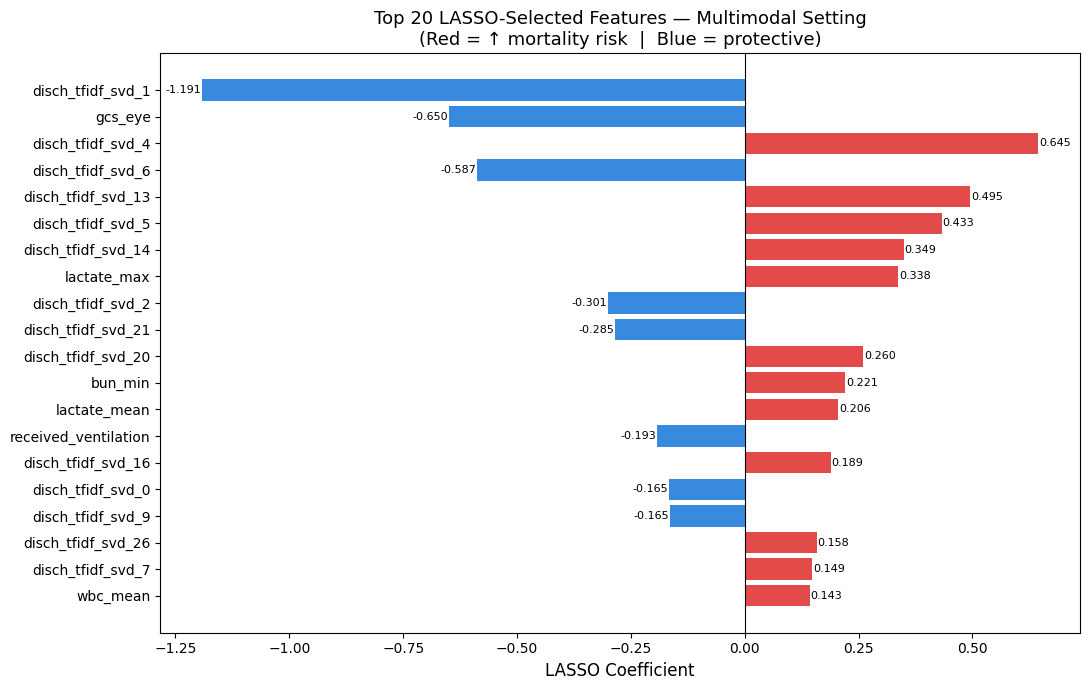

Saved: lasso_coefficients_multimodal.png


In [ ]:
# ── LASSO Coefficient Plot (paper Figure B.9 style) ───────────────
top20  = lasso_coef_df.head(20)
colors = ['#E24B4A' if c > 0 else '#378ADD' for c in top20['lasso_coef']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20['feature'], top20['lasso_coef'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LASSO Coefficient', fontsize=12)
ax.set_title(
    'Top 20 LASSO-Selected Features — Multimodal Setting\n'
    '(Red = ↑ mortality risk  |  Blue = protective)',
    fontsize=13
)
ax.invert_yaxis()

# Add value labels
for bar, val in zip(bars, top20['lasso_coef']):
    ax.text(
        val + (0.002 if val >= 0 else -0.002),
        bar.get_y() + bar.get_height()/2,
        f'{val:.3f}', va='center',
        ha='left' if val >= 0 else 'right',
        fontsize=8
    )

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lasso_coefficients_multimodal.png', dpi=150)
plt.show()
print('Saved: lasso_coefficients_multimodal.png')

## Step 4 — XGBoost Feature Selection
Paper Section 8.2:
- Gain-based importance metric
- Parameters: max_depth=3, lr=0.05, n_estimators=100, subsample=0.8
- Top 64 features selected

In [ ]:
print('='*60)
print('XGBOOST FEATURE SELECTION  (paper Section 8.2)')
print('='*60)

xgb = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=100,
    subsample=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

# Gain-based importance
scores   = xgb.get_booster().get_score(importance_type='gain')
imp_df   = pd.DataFrame(list(scores.items()), columns=['feature_idx', 'gain'])
imp_df['feature_idx'] = imp_df['feature_idx'].str.replace('f', '').astype(int)
imp_df['feature']     = [feature_cols[i] for i in imp_df['feature_idx']]
imp_df = imp_df.sort_values('gain', ascending=False)

TOP_N = 64
xgb_top = imp_df.head(TOP_N)
xgb_feats = xgb_top['feature'].tolist()

print(f'\nXGBoost selected top {TOP_N} features by gain')
print(f'Paper reports top 64 features from XGBoost in multimodal setting')
print(f'\nTop 20 XGBoost features:')
print(xgb_top[['feature','gain']].head(20).to_string(index=False))

# Overlap between LASSO and XGBoost
overlap = set(lasso_feats) & set(xgb_feats)
print(f'\nOverlapping features (LASSO ∩ XGBoost) : {len(overlap)}')
print(f'Paper reports 30 overlapping predictors')
print(f'\nOverlapping features:')
for f in sorted(overlap):
    print(f'  {f}')

# Save
imp_df.to_csv(f'{OUTPUT_DIR}/xgboost_feature_importance.csv', index=False)
print(f'\nSaved: xgboost_feature_importance.csv')

XGBOOST FEATURE SELECTION  (paper Section 8.2)

XGBoost selected top 64 features by gain
Paper reports top 64 features from XGBoost in multimodal setting

Top 20 XGBoost features:
          feature       gain
       gcs_verbal 116.585693
 bicarbonate_mean  57.943974
     lactate_mean  54.501881
          gcs_eye  42.862705
disch_tfidf_svd_1  32.872135
           pt_min  29.327232
  bicarbonate_max  27.597115
          ph_mean  27.385492
          inr_min  23.932478
disch_tfidf_svd_4  21.127659
    anion_gap_min  21.058523
          wbc_min  20.484081
      lactate_max  18.572607
disch_tfidf_svd_2  17.475250
          bun_min  17.138330
disch_tfidf_svd_0  16.884340
    platelet_mean  16.850965
disch_tfidf_svd_6  16.409319
disch_tfidf_svd_5  16.018196
          bt_mean  15.692105

Overlapping features (LASSO ∩ XGBoost) : 35
Paper reports 30 overlapping predictors

Overlapping features:
  anchor_age
  bicarbonate_max
  bt_mean
  bun_min
  calcium_mean
  disch_bert_pca_13
  disch_bert_pca_

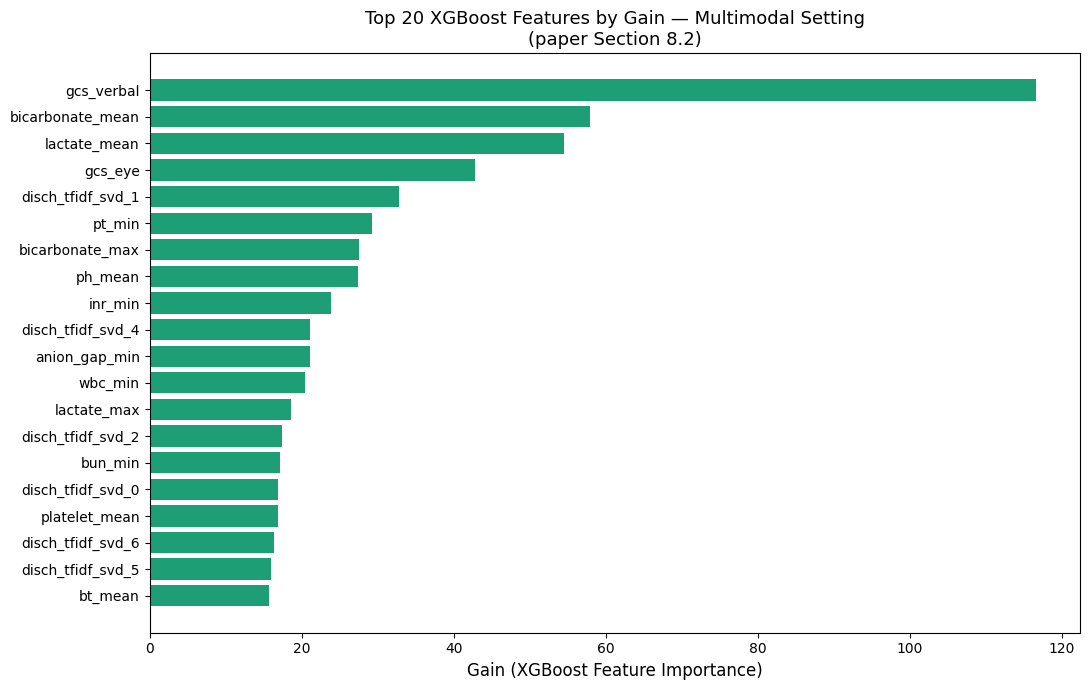

Saved: xgboost_importance_multimodal.png


In [ ]:
# ── XGBoost Top-20 Importance Plot ────────────────────────────────
top20_xgb = xgb_top.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(top20_xgb['feature'], top20_xgb['gain'], color='#1D9E75')
ax.set_xlabel('Gain (XGBoost Feature Importance)', fontsize=12)
ax.set_title(
    'Top 20 XGBoost Features by Gain — Multimodal Setting\n'
    '(paper Section 8.2)',
    fontsize=13
)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/xgboost_importance_multimodal.png', dpi=150)
plt.show()
print('Saved: xgboost_importance_multimodal.png')

## Step 5 — Univariate Screening (p < 0.05)
Paper Section 8.3: All features from LASSO ∪ XGBoost tested individually via univariate logistic regression. Only features with p < 0.05 retained.

In [ ]:
print('='*60)
print('UNIVARIATE SCREENING  (paper Section 8.3)')
print('='*60)

candidates = list(set(lasso_feats) | set(xgb_feats))
print(f'\nUnion of LASSO + XGBoost candidates : {len(candidates)}')
print(f'Paper reports 98 candidates in multimodal setting')
print('\nRunning univariate logistic regression for each...')

univariate_results = []
for col in candidates:
    x = sm.add_constant(X_train_df[col])
    try:
        res  = sm.Logit(y_train, x).fit(disp=0, maxiter=200)
        pval = res.pvalues.get(col, 1.0)
        coef = res.params.get(col, 0.0)
        univariate_results.append({
            'feature': col, 'coefficient': coef, 'p_value': pval
        })
    except Exception:
        univariate_results.append({
            'feature': col, 'coefficient': np.nan, 'p_value': 1.0
        })

univ_df = pd.DataFrame(univariate_results).sort_values('p_value')
significant_feats = univ_df[univ_df['p_value'] < 0.05]['feature'].tolist()

print(f'\nSignificant features (p < 0.05) : {len(significant_feats)}')
print(f'Paper reports 59 significant features in multimodal setting')
print(f'\nTop 20 most significant features:')
print(univ_df.head(20)[['feature','coefficient','p_value']].to_string(index=False))

# Save full table (mirrors paper Table 7.1 for multimodal)
univ_df.to_csv(f'{OUTPUT_DIR}/univariate_screening_results.csv', index=False)
print(f'\nSaved: univariate_screening_results.csv')

UNIVARIATE SCREENING  (paper Section 8.3)

Union of LASSO + XGBoost candidates : 170
Paper reports 98 candidates in multimodal setting

Running univariate logistic regression for each...

Significant features (p < 0.05) : 78
Paper reports 59 significant features in multimodal setting

Top 20 most significant features:
          feature  coefficient      p_value
          gcs_eye    -0.943715 9.822864e-70
        gcs_motor    -0.528883 4.190124e-66
disch_tfidf_svd_1    -7.542474 8.387113e-66
        gcs_total    -0.224837 8.473986e-66
 bicarbonate_mean    -0.214099 4.578962e-56
  bicarbonate_max    -0.147215 3.506061e-50
     lactate_mean     0.520346 2.381612e-46
      lactate_max     0.180482 1.416311e-43
          ph_mean    -9.738543 5.169998e-43
       gcs_verbal    -0.454425 6.095338e-42
    anion_gap_min     0.175937 5.053550e-40
           ph_min    -4.529763 4.370440e-35
  bicarbonate_min    -0.121740 6.062319e-34
           pt_min     0.203870 2.346329e-30
          bun_min   

## Step 6 — VIF Multicollinearity Check
Paper Section 8.3:
- VIF computed for all significant features
- Known collinear pairs from paper: PT/INR, Hemoglobin/Hematocrit, MBP/DBP
- Drop highest VIF iteratively until all VIF < 10
- Paper retains PT, Hemoglobin, MBP and drops INR, Hematocrit, DBP

In [ ]:
print('='*60)
print('VIF MULTICOLLINEARITY CHECK  (paper Section 8.3)')
print('='*60)

# ── Compute initial VIF for all significant features ──────────────
def compute_vif(df_subset, features):
    X_sub = df_subset[features].values.astype(float)
    vif_data = []
    for i, feat in enumerate(features):
        try:
            vif = variance_inflation_factor(X_sub, i)
        except Exception:
            vif = np.nan
        vif_data.append({'feature': feat, 'VIF': vif})
    return pd.DataFrame(vif_data).sort_values('VIF', ascending=False)

print(f'\nStarting with {len(significant_feats)} significant features...')

## ── Paper-guided manual drops first (known pairs — Section 8.3) ───
known_drops = []

# 1. Known collinear pairs: keep PT, Hemoglobin, MBP; drop their counterparts
for pair in [('inr_mean','pt_mean'), ('inr_min','pt_min'), ('inr_max','pt_max'),
             ('hematocrit_mean','hemoglobin_mean'), ('hematocrit_min','hemoglobin_min'),
             ('hematocrit_max','hemoglobin_max'),
             ('dbp_mean','mbp_mean'), ('dbp_min','mbp_min'), ('dbp_max','mbp_max')]:
    drop_col, keep_col = pair
    if drop_col in significant_feats and keep_col in significant_feats:
        known_drops.append(drop_col)
        print(f'  Manual drop: {drop_col} (collinear with {keep_col})')

# 2. GCS components: perfectly collinear with gcs_total by definition
#    (gcs_total = gcs_eye + gcs_verbal + gcs_motor always)
#    Paper Tables 7.2–7.4 only use GCS Total in all models
for comp in ['gcs_eye', 'gcs_verbal', 'gcs_motor']:
    if comp in significant_feats:
        known_drops.append(comp)
        print(f'  Manual drop: {comp} (component of gcs_total — perfect collinearity)')

working_feats = [f for f in significant_feats if f not in known_drops]
print(f'  After manual drops: {len(working_feats)} features')

# ── Paper approach: VIF is DIAGNOSTIC only — no iterative dropping ─
# FIX: Paper Section 8.3 removes only the 3 known collinear pairs
# (INR/PT, Hematocrit/Hemoglobin, DBP/MBP) and then reports VIFs
# to confirm acceptability. It does NOT run an automated iterative
# elimination loop, which would strip core clinical variables.
final_feats_combined = working_feats.copy()

print(f'\nFinal combined feature set : {len(final_feats_combined)} features')
print(f'Paper reports 56 features in final combined multimodal model')
print('\nVIF scores (diagnostic — no further auto-drops per paper):')

# Final VIF table (mirrors paper Table A.3)
final_vif_df = compute_vif(X_train_df, final_feats_combined)
print(f'\nFinal VIF scores:')
print(final_vif_df.to_string(index=False))

final_vif_df.to_csv(f'{OUTPUT_DIR}/final_vif_scores.csv', index=False)
print(f'\nSaved: final_vif_scores.csv')

VIF MULTICOLLINEARITY CHECK  (paper Section 8.3)

Starting with 78 significant features...
  Manual drop: inr_mean (collinear with pt_mean)
  Manual drop: inr_min (collinear with pt_min)
  Manual drop: hematocrit_max (collinear with hemoglobin_max)
  Manual drop: gcs_eye (component of gcs_total — perfect collinearity)
  Manual drop: gcs_verbal (component of gcs_total — perfect collinearity)
  Manual drop: gcs_motor (component of gcs_total — perfect collinearity)
  After manual drops: 72 features

Final combined feature set : 72 features
Paper reports 56 features in final combined multimodal model

VIF scores (diagnostic — no further auto-drops per paper):

Final VIF scores:
             feature         VIF
             ph_mean 9882.339317
             bt_mean 7917.424938
              ph_min 6274.148308
              bt_min 4215.993679
           spo2_mean  860.007704
    bicarbonate_mean  370.424691
        chloride_min  334.645709
      potassium_mean  226.441737
     bicarbonate_max

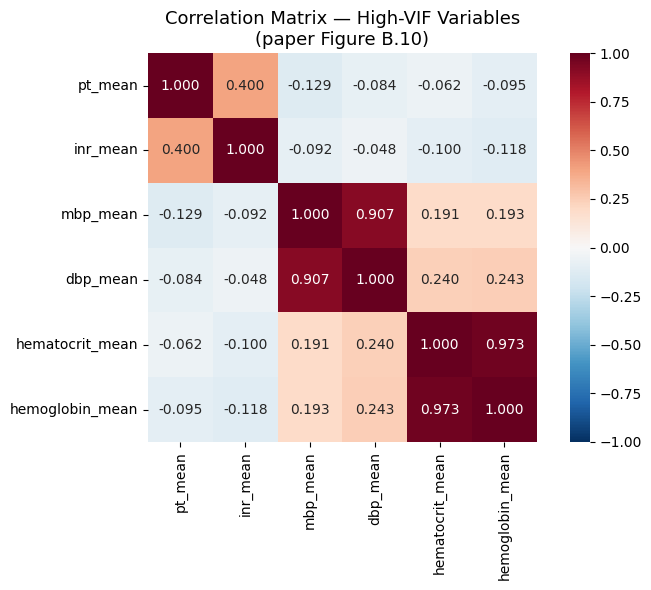

Saved: vif_correlation_matrix.png


In [ ]:
# ── Correlation matrix of high-VIF variables (paper Figure B.10) ──
# Show only variables with structural collinearity
corr_vars = [
    c for c in ['pt_mean','inr_mean','mbp_mean','dbp_mean',
                'hematocrit_mean','hemoglobin_mean']
    if c in X_train_df.columns
]

if len(corr_vars) >= 2:
    corr_matrix = X_train_df[corr_vars].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        corr_matrix,
        annot=True, fmt='.3f', cmap='RdBu_r',
        center=0, vmin=-1, vmax=1,
        ax=ax, square=True
    )
    ax.set_title(
        'Correlation Matrix — High-VIF Variables\n'
        '(paper Figure B.10)',
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/vif_correlation_matrix.png', dpi=150)
    plt.show()
    print('Saved: vif_correlation_matrix.png')

## Step 7 — Three Multivariate Logistic Regression Models
Paper Section 8.4 (mirrors Table 8.1):
- **Model 1** — LASSO-selected features only → after univariate p<0.05 + VIF
- **Model 2** — XGBoost-selected features only → after univariate p<0.05 + VIF
- **Model 3** — Combined (union, VIF-filtered) → best fit

Uses `statsmodels.Logit` for interpretable coefficients, CIs, p-values.

In [ ]:
print('='*60)
print('THREE LOGISTIC REGRESSION MODELS  (paper Section 8.4)')
print('='*60)

def prepare_features_for_model(candidate_feats, X_train_df, y_train):
    """Apply univariate screening + VIF filter to a feature set."""
    # Univariate p < 0.05
    sig = []
    for col in candidate_feats:
        if col not in X_train_df.columns:
            continue
        x = sm.add_constant(X_train_df[col])
        try:
            res  = sm.Logit(y_train, x).fit(disp=0, maxiter=200)
            pval = res.pvalues.get(col, 1.0)
            if pval < 0.05:
                sig.append(col)
        except Exception:
            pass

    # ── FIX: only drop the known collinear pairs (paper Section 8.3)
    # No iterative VIF loop — that would remove core clinical variables.
    working = sig.copy()
    for pair in [('inr_mean','pt_mean'),('inr_min','pt_min'),('inr_max','pt_max'),
                 ('hematocrit_mean','hemoglobin_mean'),('hematocrit_min','hemoglobin_min'),
                 ('hematocrit_max','hemoglobin_max'),
                 ('dbp_mean','mbp_mean'),('dbp_min','mbp_min'),('dbp_max','mbp_max')]:
        if pair[0] in working and pair[1] in working:
            working.remove(pair[0])

    return working


def fit_logistic_model(X_train_df, y_train, features, model_name):
    """Fit statsmodels Logit. Returns model object."""
    print(f'\n  Fitting {model_name} ({len(features)} features)...')
    X = sm.add_constant(X_train_df[features])
    try:
        model = sm.Logit(y_train, X).fit(disp=0, maxiter=500)
        print(f'  Pseudo-R² : {model.prsquared:.4f}')
        return model
    except Exception as e:
        print(f'  ⚠️  Failed: {e}')
        return None


# ── Prepare feature sets for each model ──────────────────────────
print('\nPreparing LASSO model feature set...')
lasso_model_feats = prepare_features_for_model(lasso_feats, X_train_df, y_train)
print(f'  LASSO model features : {len(lasso_model_feats)}')
print(f'  Paper: 46 significant from LASSO')

print('\nPreparing XGBoost model feature set...')
xgb_model_feats = prepare_features_for_model(xgb_feats, X_train_df, y_train)
print(f'  XGBoost model features : {len(xgb_model_feats)}')
print(f'  Paper: 37 significant from XGBoost')

print(f'\nCombined model features : {len(final_feats_combined)}')
print(f'Paper: 56 features in combined model')

# ── Fit three models ──────────────────────────────────────────────
print('\n' + '='*60)
print('Fitting models...')
model_lasso = fit_logistic_model(X_train_df, y_train, lasso_model_feats,    'Model 1: LASSO')
model_xgb   = fit_logistic_model(X_train_df, y_train, xgb_model_feats,      'Model 2: XGBoost')
model_comb  = fit_logistic_model(X_train_df, y_train, final_feats_combined,  'Model 3: Combined')

# ── Print model summaries ─────────────────────────────────────────
print('\n' + '='*60)
print('MODEL COMPARISON TABLE  (paper Table 8.1)')
print('='*60)
print("{:<30} {:>12} {:>12}".format("Model", "# Features", "Pseudo-R²"))
print('-'*56)
for m, name, n_feat in [
    (model_lasso, 'LASSO (Structured+Text)',    len(lasso_model_feats)),
    (model_xgb,   'XGBoost (Structured+Text)',  len(xgb_model_feats)),
    (model_comb,  'Combined (Structured+Text)', len(final_feats_combined)),
]:
    r2 = f'{m.prsquared:.4f}' if m is not None else 'N/A'
    print(f'{name:<30} {n_feat:>12} {r2:>12}')
print('-'*56)
print("{:<30} {:>12} {:>12}".format("Paper LASSO", "46", "0.5226"))
print("{:<30} {:>12} {:>12}".format("Paper XGBoost", "37", "0.4653"))
print("{:<30} {:>12} {:>12}".format("Paper Combined", "56", "0.5258"))

# Save full summaries
for m, name in [(model_lasso,'lasso'),(model_xgb,'xgb'),(model_comb,'combined')]:
    if m is not None:
        with open(f'{OUTPUT_DIR}/model_{name}_summary.txt', 'w') as f:
            f.write(m.summary().as_text())
        print(f'Saved: model_{name}_summary.txt')

THREE LOGISTIC REGRESSION MODELS  (paper Section 8.4)

Preparing LASSO model feature set...
  LASSO model features : 59
  Paper: 46 significant from LASSO

Preparing XGBoost model feature set...
  XGBoost model features : 44
  Paper: 37 significant from XGBoost

Combined model features : 72
Paper: 56 features in combined model

Fitting models...

  Fitting Model 1: LASSO (59 features)...
  Pseudo-R² : 0.6251

  Fitting Model 2: XGBoost (44 features)...
  Pseudo-R² : 0.5695

  Fitting Model 3: Combined (72 features)...
  Pseudo-R² : 0.6347

MODEL COMPARISON TABLE  (paper Table 8.1)
Model                            # Features    Pseudo-R²
--------------------------------------------------------
LASSO (Structured+Text)                  59       0.6251
XGBoost (Structured+Text)                44       0.5695
Combined (Structured+Text)               72       0.6347
--------------------------------------------------------
Paper LASSO                              46       0.5226
Paper XGBoost

## Step 8 — Full Model Evaluation
Paper Section 8.5:
- ROC curves with AUC (Figure 8.1)
- Calibration curves (Figure B.7)
- Decision Curve Analysis (Figure 8.2)
- Summary metrics table (Table 8.2)

In [ ]:
print('='*60)
print('MODEL EVALUATION  (paper Section 8.5)')
print('='*60)

def evaluate_model(model, X_test_df, y_test, features, model_name):
    """Compute all evaluation metrics."""
    if model is None:
        return None
    X_te = sm.add_constant(X_test_df[features], has_constant='add')
    try:
        y_prob = model.predict(X_te)
    except Exception as e:
        print(f'  Prediction failed for {model_name}: {e}')
        return None

    y_pred = (y_prob >= 0.5).astype(int)
    auc    = roc_auc_score(y_test, y_prob)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)

    return {
        'model_name': model_name,
        'AUC': auc, 'Accuracy': acc, 'F1': f1, 'Recall': rec,
        'y_prob': y_prob, 'y_pred': y_pred
    }

r_lasso = evaluate_model(model_lasso, X_test_df, y_test, lasso_model_feats,   'LASSO')
r_xgb   = evaluate_model(model_xgb,   X_test_df, y_test, xgb_model_feats,     'XGBoost')
r_comb  = evaluate_model(model_comb,  X_test_df, y_test, final_feats_combined, 'Combined LogReg')

results = [r for r in [r_lasso, r_xgb, r_comb] if r is not None]

# Print per-model classification reports
for res in results:
    print('-'*56)
    print(f"{res['model_name']}")
    print(f"  AUC      : {res['AUC']:.4f}   (paper LASSO=0.91, XGB=0.88, Combined=0.92)")
    print(f"  Accuracy : {res['Accuracy']:.4f}   (paper: 0.84)")
    print(f"  F1       : {res['F1']:.4f}   (paper: 0.85)")
    print(f"  Recall   : {res['Recall']:.4f}   (paper: 0.88)")
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Survived','Died']
    ))

MODEL EVALUATION  (paper Section 8.5)
--------------------------------------------------------
LASSO
  AUC      : 0.9453   (paper LASSO=0.91, XGB=0.88, Combined=0.92)
  Accuracy : 0.8939   (paper: 0.84)
  F1       : 0.9018   (paper: 0.85)
  Recall   : 0.9298   (paper: 0.88)
              precision    recall  f1-score   support

    Survived       0.92      0.85      0.88       220
        Died       0.88      0.93      0.90       242

    accuracy                           0.89       462
   macro avg       0.90      0.89      0.89       462
weighted avg       0.90      0.89      0.89       462

--------------------------------------------------------
XGBoost
  AUC      : 0.9379   (paper LASSO=0.91, XGB=0.88, Combined=0.92)
  Accuracy : 0.8723   (paper: 0.84)
  F1       : 0.8813   (paper: 0.85)
  Recall   : 0.9050   (paper: 0.88)
              precision    recall  f1-score   support

    Survived       0.89      0.84      0.86       220
        Died       0.86      0.90      0.88       

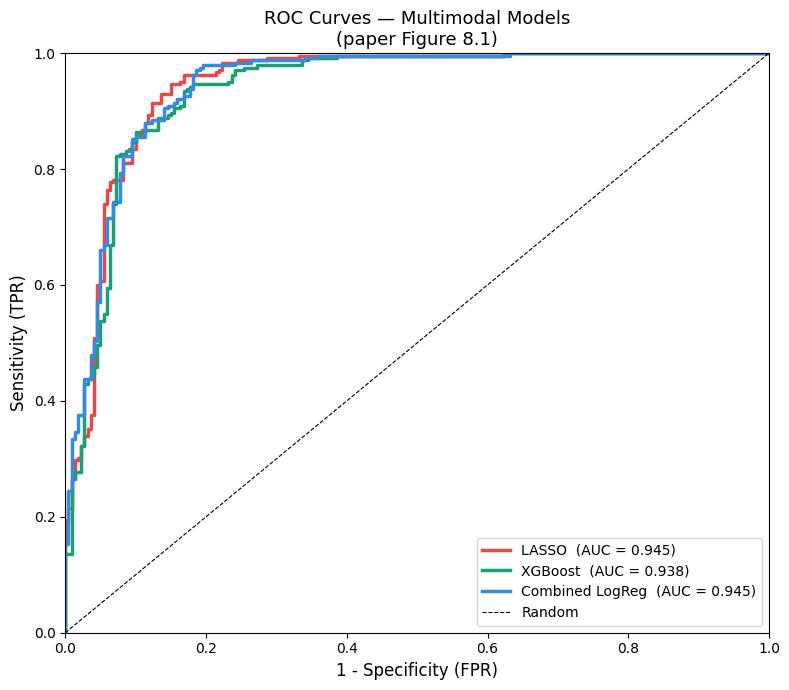

Saved: roc_curves_multimodal.png


In [ ]:
# ── ROC Curves (paper Figure 8.1) ─────────────────────────────────
colors = ['#E24B4A', '#1D9E75', '#378ADD', '#F5A623']

fig, ax = plt.subplots(figsize=(8, 7))
for i, res in enumerate(results):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2.5, color=colors[i],
            label=f"{res['model_name']}  (AUC = {res['AUC']:.3f})")

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Random')
ax.set_xlabel('1 - Specificity (FPR)', fontsize=12)
ax.set_ylabel('Sensitivity (TPR)', fontsize=12)
ax.set_title(
    'ROC Curves — Multimodal Models\n'
    '(paper Figure 8.1)',
    fontsize=13
)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves_multimodal.png', dpi=150)
plt.show()
print('Saved: roc_curves_multimodal.png')

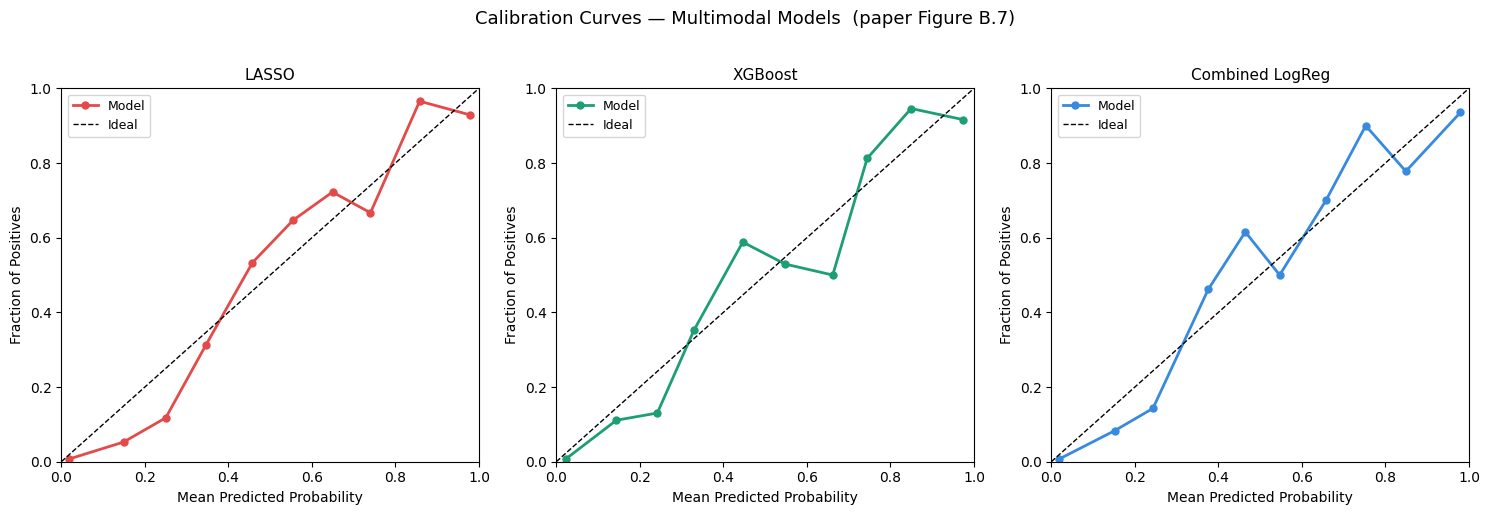

Saved: calibration_multimodal.png


In [ ]:
# ── Calibration Curves (paper Figure B.7) ─────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, res, col in zip(axes, results, colors):
    frac_pos, mean_pred = calibration_curve(
        y_test, res['y_prob'], n_bins=10)
    ax.plot(mean_pred, frac_pos, marker='o', color=col,
            linewidth=2, markersize=5, label='Model')
    ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Ideal')
    ax.set_title(res['model_name'], fontsize=11)
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle(
    'Calibration Curves — Multimodal Models  (paper Figure B.7)',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/calibration_multimodal.png', dpi=150,
            bbox_inches='tight')
plt.show()
print('Saved: calibration_multimodal.png')

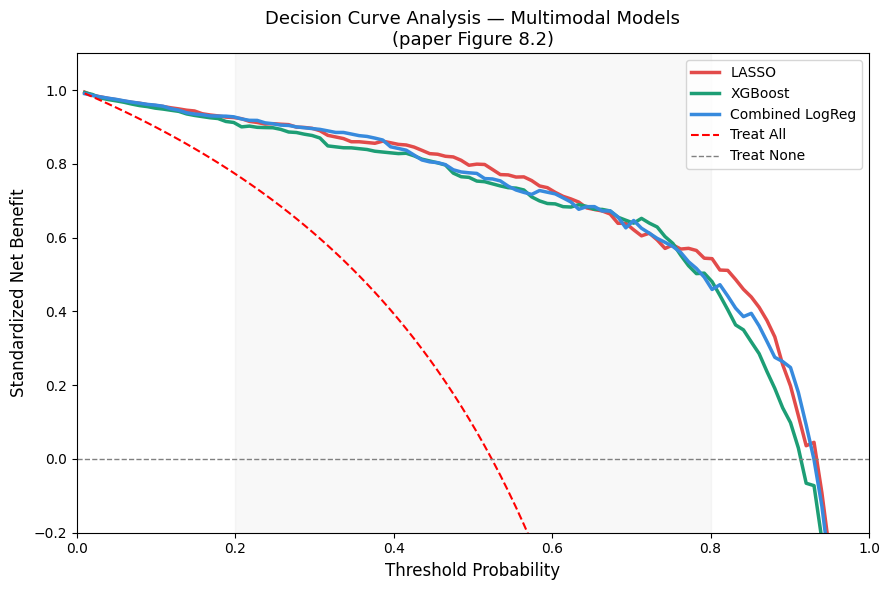

Saved: decision_curve_multimodal.png


In [ ]:
# ── Decision Curve Analysis (paper Figure 8.2) ────────────────────
n    = len(y_test)
prev = y_test.mean()
thres = np.linspace(0.01, 0.99, 100)

fig, ax = plt.subplots(figsize=(9, 6))

for res, col in zip(results, colors):
    nb = []
    for pt in thres:
        pred_pos = res['y_prob'] >= pt
        tp = ((pred_pos) & (y_test == 1)).sum()
        fp = ((pred_pos) & (y_test == 0)).sum()
        nb.append(((tp/n) - (fp/n)*(pt/(1-pt))) / prev)
    ax.plot(thres, nb, linewidth=2.5, color=col,
            label=res['model_name'])

# Treat-all baseline
nb_all = [1 - (1-prev)/prev * pt/(1-pt) for pt in thres]
ax.plot(thres, nb_all, 'r--', linewidth=1.5, label='Treat All')
ax.axhline(0, color='gray', linewidth=1, linestyle='--', label='Treat None')

ax.set_xlabel('Threshold Probability', fontsize=12)
ax.set_ylabel('Standardized Net Benefit', fontsize=12)
ax.set_title(
    'Decision Curve Analysis — Multimodal Models\n'
    '(paper Figure 8.2)',
    fontsize=13
)
ax.legend(fontsize=10)
ax.set_xlim(0, 1); ax.set_ylim(-0.2, 1.1)

# Shade clinically relevant range (paper: 0.2–0.8)
ax.axvspan(0.2, 0.8, alpha=0.05, color='gray',
           label='Clinical range (0.2–0.8)')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/decision_curve_multimodal.png', dpi=150)
plt.show()
print('Saved: decision_curve_multimodal.png')

In [ ]:
# ── Final Summary Table (paper Table 8.2) ─────────────────────────
print('='*65)
print('FINAL SUMMARY TABLE  (paper Table 8.2)')
print('='*65)
print(f"{'Model':<30} {'AUC':>7} {'Accuracy':>9} {'F1':>7} {'Recall':>8}")
print('─'*65)

summary_rows = []
for res in results:
    print(
        f"{res['model_name']:<30} "
        f"{res['AUC']:>7.4f} "
        f"{res['Accuracy']:>9.4f} "
        f"{res['F1']:>7.4f} "
        f"{res['Recall']:>8.4f}"
    )
    summary_rows.append({
        'Model': res['model_name'],
        'AUC': res['AUC'],
        'Accuracy': res['Accuracy'],
        'F1': res['F1'],
        'Recall': res['Recall']
    })

print('─'*65)
print(f"{'Paper: Structured+Text (best)':<30} {'0.9180':>7} {'0.84':>9} {'0.85':>7} {'0.88':>8}")
print(f"{'Paper: Structured only (best)':<30} {'0.7534':>7} {'0.68':>9} {'0.70':>7} {'0.71':>8}")
print('='*65)

# Save summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f'{OUTPUT_DIR}/model_evaluation_summary.csv', index=False)
print(f'\nSaved: model_evaluation_summary.csv')
print(f'\nAll outputs saved to: {OUTPUT_DIR}')

FINAL SUMMARY TABLE  (paper Table 8.2)
Model                              AUC  Accuracy      F1   Recall
─────────────────────────────────────────────────────────────────
LASSO                           0.9453    0.8939  0.9018   0.9298
XGBoost                         0.9379    0.8723  0.8813   0.9050
Combined LogReg                 0.9449    0.8831  0.8920   0.9215
─────────────────────────────────────────────────────────────────
Paper: Structured+Text (best)   0.9180      0.84    0.85     0.88
Paper: Structured only (best)   0.7534      0.68    0.70     0.71

Saved: model_evaluation_summary.csv

All outputs saved to: C:\Users\anura\Downloads\MERGER\outputs\finalmergedoutputs
